In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
DATA_PATH = r"F:\MultiDimensionalAD\data\202505161524GMT+5x30.h24.csv"

In [5]:
df = pd.read_csv(DATA_PATH)

In [6]:
df

,Seconds,Timestamp_IST,MU-FIC-1103-S,I2-FIc-2206-S,I2-FIc-2205-S,WA-FIC-1203-S,I2-FIc-2253-S,MA-FIC-1303-S,MA-FIC-1353-S,I2-FIC-4203,...,WA-MP-101B,WA-MP-101C,GUJRI-DRA-PUMP,MANMAD-DRA-PUMP,MG-DRA-PUMP,GUJRI-DRA-TYPE,MANMAD-DRA-TYPE,MG-DRA-TYPE,MU-DRA-TYPE,WA-DRA-TYPE
0,0,2025-05-16 15:24:45,1170.94,0,564.942,1168.76,0,605.546,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,2025-05-16 15:24:50,1170.43,0,566.561,1168.80,0,605.546,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10,2025-05-16 15:24:55,1170.43,0,566.561,1168.80,0,608.734,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,2025-05-16 15:25:00,1170.71,0,564.942,1169.49,0,605.546,0,0,...,0,0,0,0,0,0,0,0,0,0
4,20,2025-05-16 15:25:05,1171.94,0,564.942,1168.43,0,608.734,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17251,86255,2025-05-17 15:22:20,1176.34,0,588.555,1174.47,0,815.894,0,0,...,0,0,0,0,0,0,0,0,0,0
17252,86260,2025-05-17 15:22:25,1175.35,0,590.176,1174.09,0,812.707,0,0,...,0,0,0,0,0,0,0,0,0,0
17253,86265,2025-05-17 15:22:30,1175.35,0,588.555,1173.19,0,815.894,0,0,...,0,0,0,0,0,0,0,0,0,0
17254,86270,2025-05-17 15:22:35,1176.94,0,588.555,1174.88,0,815.894,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
sensor_cols = [
    c for c in df.columns
    if any(k in c for k in ['TI', 'PI', 'PIC', 'FI', 'FIC'])
]
df_sensors = df[sensor_cols]
std = {}

for c in sensor_cols:
    std[c] = df[c].std()


In [32]:
import pandas as pd

std_df = pd.DataFrame({
    'sensor': list(std.keys()),
    'std': list(std.values())
})


In [28]:
import plotly.express as px

fig = px.bar(
    std_df,
    x='sensor',
    y='std',
    title='Sensor Standard Deviation (Static Anomaly Screening)'
)

fig.update_layout(
    xaxis_title='Sensor',
    yaxis_title='Standard Deviation',
    xaxis_tickangle=-90,     # 🔥 vertical labels
    height=800,              # more vertical space
    margin=dict(b=300)       # space for long labels
)


In [35]:
# df_when_SA-MOV-1802 is 1
df_sa = df[df['SA-MOV-1802'] == 1]
df_sa

,Seconds,Timestamp_IST,MU-FIC-1103-S,I2-FIc-2206-S,I2-FIc-2205-S,WA-FIC-1203-S,I2-FIc-2253-S,MA-FIC-1303-S,MA-FIC-1353-S,I2-FIC-4203,...,WA-MP-101B,WA-MP-101C,GUJRI-DRA-PUMP,MANMAD-DRA-PUMP,MG-DRA-PUMP,GUJRI-DRA-TYPE,MANMAD-DRA-TYPE,MG-DRA-TYPE,MU-DRA-TYPE,WA-DRA-TYPE
13546,67730,2025-05-17 10:13:35,1177.89,0,583.808,1176.21,0,812.707,0,0,...,0,0,0,0,0,0,0,0,0,0
13547,67735,2025-05-17 10:13:40,1177.67,0,583.808,1173.07,0,812.707,0,0,...,0,0,0,0,0,0,0,0,0,0
13548,67740,2025-05-17 10:13:45,1177.67,0,585.430,1174.80,0,812.707,0,0,...,0,0,0,0,0,0,0,0,0,0
13549,67745,2025-05-17 10:13:50,1179.18,0,585.430,1176.19,0,809.520,0,0,...,0,0,0,0,0,0,0,0,0,0
13550,67750,2025-05-17 10:13:55,1179.18,0,585.430,1175.69,0,812.707,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14621,73105,2025-05-17 11:43:10,1164.98,0,577.322,1166.82,0,1169.660,0,0,...,0,0,0,0,0,0,0,0,0,0
14622,73110,2025-05-17 11:43:15,1164.17,0,575.700,1167.18,0,1169.660,0,0,...,0,0,0,0,0,0,0,0,0,0
14623,73115,2025-05-17 11:43:20,1164.17,0,577.322,1164.95,0,1172.850,0,0,...,0,0,0,0,0,0,0,0,0,0
14624,73120,2025-05-17 11:43:25,1164.55,0,575.700,1164.95,0,1169.660,0,0,...,0,0,0,0,0,0,0,0,0,0


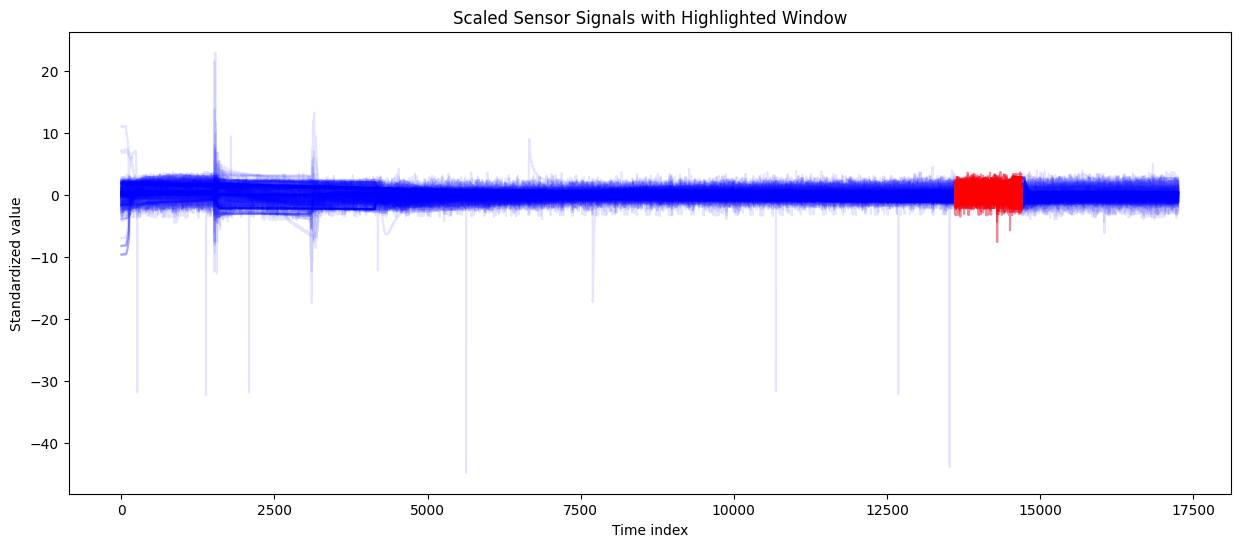

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

START = 13615
LEN = 1080
END = START + LEN

# 1️⃣ Scale ONCE
scaler = StandardScaler()
scaled = scaler.fit_transform(df[sensor_cols].values)

plt.figure(figsize=(15, 6))

# 2️⃣ Plot all sensors in blue
for i in range(scaled.shape[1]):
    plt.plot(scaled[:, i], color='blue', alpha=0.1)

# 3️⃣ Overlay the SAME sensors, SAME scale, but only window in red
for i in range(scaled.shape[1]):
    plt.plot(
        np.arange(START, END),
        scaled[START:END, i],
        color='red',
        alpha=0.4
    )

plt.title("Scaled Sensor Signals with Highlighted Window")
plt.xlabel("Time index")
plt.ylabel("Standardized value")
plt.show()


In [26]:
operational_figs = [
    c for c in df.columns
    if any(k in c for k in ['MOV', 'MP'])
]
df_ops = df[operational_figs]
std = {}

for c in operational_figs:
    std[c] = df[c].std()

In [27]:
import pandas as pd

std_df = pd.DataFrame({
    'sensor': list(std.keys()),
    'std': list(std.values())
})
